### <font size=7> 11장 모멘텀 포트폴리오 투자 전략</font>

### 코드 11-1 CAPM 테스트

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

aapl = yf.download('AAPL', start='2014-01-01', end='2024-01-01', multi_level_index=False, auto_adjust=False)['Adj Close']
snp = yf.download('^SPX', start='2014-01-01', end='2024-01-01', multi_level_index=False, auto_adjust=False)['Adj Close']

# 월간 수익률 계산
aapl_ret = (aapl.pct_change()+1)[1:].resample('BME').prod() - 1
snp_ret = (snp.pct_change()+1)[1:].resample('BME').prod() - 1

# 월 이자율
R_f = 0.03/12

# 선형 회귀
X = snp_ret - R_f
Y = aapl_ret - R_f
X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()

print(model.summary())

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

                            OLS Regression Results                            
Dep. Variable:              Adj Close   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     110.6
Date:                Thu, 31 Oct 2024   Prob (F-statistic):           1.18e-18
Time:                        13:47:41   Log-Likelihood:                 172.54
No. Observations:                 120   AIC:                            -341.1
Df Residuals:                     118   BIC:                            -335.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0127      0.005      2.373      0.0

### 그림 11-1 AAPL의 월간 초과 수익률에 대한 선형 회귀 결과

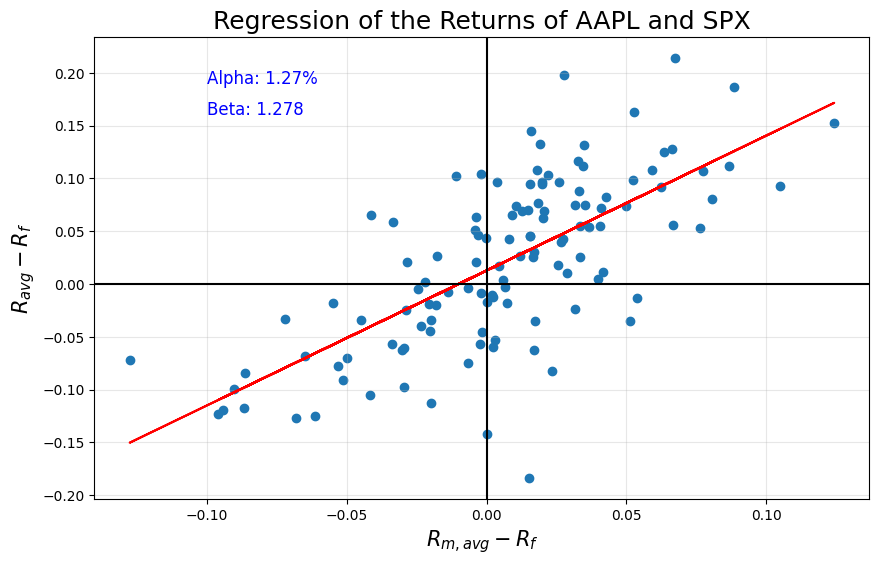

In [2]:
# 알파, 베타
alpha, beta = model.params

# 선형 근사식
pred = alpha + beta*X

# 시각화
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(X,Y)
ax.plot(X,pred, c='r')
ax.axhline(y=0, color='black', linewidth=1.5)
ax.axvline(x=0, color='black', linewidth=1.5)

ax.text(-0.1, 0.19, f'Alpha: {100*alpha:.2f}%', fontsize=12, color='blue')
ax.text(-0.1, 0.16, f'Beta: {beta:.3f}', fontsize=12, color='blue')

ax.set_title('Regression of the Returns of AAPL and SPX', fontsize=18)
ax.set_xlabel('$R_{m,avg} - R_f$', fontsize=15)
ax.set_ylabel('$R_{avg}-R_f$', fontsize=15)
ax.grid(alpha=0.3)
plt.show()

### 코드 11-2 과거 10년간 S&P 500 지수의 성과

[*********************100%%**********************]  1 of 1 completed


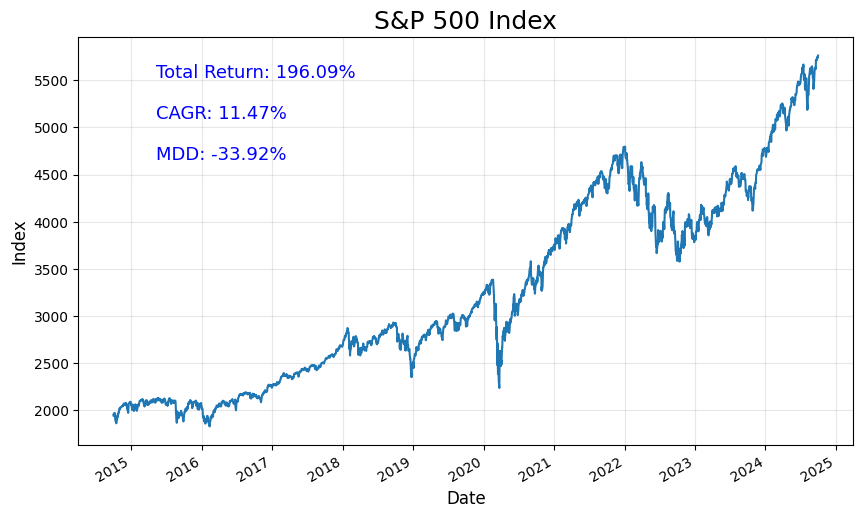

In [3]:
# S&P 500 지수 데이터 다운로드
snp = yf.download('^SPX', start='2014-10-01', end='2024-10-01', multi_level_index=False, auto_adjust=False)['Adj Close']

# 벤치마크 누적 수익률
snp_cum_ret = snp/snp.iloc[0]

# 벤치마크 최종 수익률
benchmark_total_return = snp_cum_ret.iloc[-1] - 1

# 벤치마크 CAGR
CAGR_benchmark = (benchmark_total_return + 1)**(1/10) - 1

# 벤치마크 MDD
MDD_benchmark = ( snp_cum_ret / (snp_cum_ret.cummax()) - 1 ).min()

# 벤치마크 그래프
fig, ax = plt.subplots(figsize=(10,6))

snp.plot(ax=ax, linewidth=1.5)
ax.text(0.1, 0.9, f'Total Return: {100*benchmark_total_return:.2f}%', \
        transform=ax.transAxes, fontsize=13, color='blue')
ax.text(0.1, 0.8, f'CAGR: {100*CAGR_benchmark:.2f}%', transform=ax.transAxes, \
        fontsize=13, color='blue')
ax.text(0.1, 0.7, f'MDD: {100*MDD_benchmark:.2f}%', transform=ax.transAxes, \
        fontsize=13, color='blue')

ax.set_title('S&P 500 Index', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Index', fontsize=12)
ax.grid(alpha=0.3)
plt.show()

### 코드 11-3 S&P 500 전종목 수정종가 가져오기

In [4]:
# S&P 500 종목 티커 가져오기
ticker_df = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
tickers = ticker_df.Symbol.to_list()

#  S&P 500 전 종목 수정 종가 다운로드
df = yf.download(tickers, start='2013-10-01', end='2024-10-01', multi_level_index=False, auto_adjust=False)['Adj Close']

# 결측치 제거
df.dropna(axis=1, inplace=True)

# 데이터프레임 출력
df

[**********************78%%***********           ]  394 of 503 completed

$BF.B: possibly delisted; No price data found  (1d 2013-10-01 -> 2024-10-01)


[*********************100%%**********************]  503 of 503 completed

2 Failed downloads:
['BRK.B']: YFTzMissingError('$%ticker%: possibly delisted; No timezone found')
['BF.B']: YFPricesMissingError('$%ticker%: possibly delisted; No price data found  (1d 2013-10-01 -> 2024-10-01)')


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2013-10-01,33.851452,15.132128,29.071396,27.191639,18.299999,60.210228,52.430000,37.074162,27.281332,49.729786,...,96.813278,18.961393,131.379990,19.506952,54.167084,24.500319,41.699646,73.252899,46.570000,29.305857
2013-10-02,33.636215,15.181741,29.166607,27.288225,18.373333,59.957371,51.520000,36.830212,27.525654,49.633286,...,96.791351,18.922327,132.430557,19.485901,54.217434,24.396212,41.186996,73.795074,46.599998,29.508722
2013-10-03,33.303566,14.991023,29.204699,26.797201,18.186666,59.655590,50.880001,36.452457,27.207300,48.999275,...,94.794952,18.727055,131.864227,19.134933,53.852116,24.205343,41.035530,73.475060,46.169998,29.029209
2013-10-04,33.773190,14.979238,29.706137,27.014547,18.323334,59.753479,51.570000,36.979740,27.170284,49.288727,...,95.453125,18.609892,131.470261,19.163010,54.368591,24.448267,41.670532,74.123985,46.520000,29.554831
2013-10-07,33.349228,15.125617,29.255468,26.966242,18.316668,59.011223,50.820000,36.704292,26.963003,48.944157,...,94.575569,18.616404,130.534576,19.071751,54.104088,24.292103,41.612267,73.963974,46.139999,29.444178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24,141.644501,227.369995,191.976959,112.808334,113.349998,338.243225,524.070007,227.330002,60.730000,276.640015,...,288.341431,33.779999,84.160004,64.169998,117.050003,133.039993,133.800003,107.570908,364.429993,193.690002
2024-09-25,139.218369,226.369995,189.744781,112.081764,113.070000,335.683624,517.900024,226.639999,58.139999,275.250000,...,289.517914,32.970001,84.129997,64.190002,114.769997,133.610001,133.089996,106.263817,364.970001,191.529999
2024-09-26,146.506775,227.520004,190.379700,112.201210,112.570000,354.367584,515.380005,232.460007,59.369999,274.429993,...,290.285583,33.160000,91.029999,63.980000,112.800003,134.130005,138.070007,107.471130,371.239990,194.869995


### 코드 11-4 월단위 수익률 계산하기

In [5]:
# 월단위 수익률 계산
m_ret = (df.pct_change()+1)[1:].resample('BME').prod()
print(m_ret.iloc[:5,:5])

Ticker             A      AAPL      ABBV       ABT      ACGL
Date                                                        
2013-10-31  0.978035  1.071194  1.067389  1.086587  1.055738
2013-11-29  1.055359  1.070053  1.000000  1.044870  1.015010
2013-12-31  1.070033  1.008902  1.089990  1.003666  1.014618
2014-01-31  1.016786  0.892303  0.939593  0.961778  0.901491
2014-02-28  0.979020  1.057511  1.034126  1.085106  1.042929


### 코드 11-5 11개월 롤링 누적 수익률 계산과 종목 선정

In [6]:
# 11개월 롤링 누적 수익률 계산
ret_11m = m_ret.rolling(11).apply(np.prod)

# 직전 11개월 누적 수익률 상위 10개 종목 출력
top_tickers = ret_11m.loc['2014-08-29'].nlargest(10).index
print(list(top_tickers))

['SWKS', 'LUV', 'FANG', 'URI', 'AVGO', 'TRGP', 'PANW', 'MU', 'HPQ', 'NXPI']


### 코드 11-6 리벨런싱 구현 준비

In [7]:
date1 = '2014-08-29' # 구성일의 1개월 전일
date2 = '2014-09-30' # 포트폴리오 구성일

top_tickers = ret_11m.loc[date1].nlargest(25).index
m_ret.loc[date2:, top_tickers][:3]

Ticker,SWKS,LUV,FANG,URI,AVGO,TRGP,PANW,MU,HPQ,NXPI,...,WMB,RCL,FSLR,MAR,DAL,EXPE,VLO,WDC,CMG,LYB
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-30,1.024532,1.054983,0.866010,0.944326,1.063684,0.975779,1.154253,1.050920,0.937412,0.998687,...,0.940356,1.060045,0.944460,1.007204,0.913340,1.020023,0.854636,0.944763,0.982229,0.950240
2014-10-31,1.003273,1.021024,0.915218,0.990639,0.991379,0.950050,1.077472,0.965849,1.011559,1.003361,...,1.002891,1.010106,0.895001,1.083691,1.112863,0.969755,1.082559,1.014961,0.957110,0.843273
2014-11-28,1.160969,1.212877,0.824079,1.029529,1.082899,0.887351,1.163671,1.086431,1.088629,1.133265,...,0.932264,1.084890,0.828523,1.042835,1.162552,1.027313,0.975874,1.049812,1.040157,0.867431


### 코드 11-7 포트폴리오 운용 시뮬레이션

In [8]:
# 월말 영업일 
dates = m_ret.loc['2014-08-29':'2024-09-30'].index

# 포트폴리오 구성일
form_dates = dates[1:-1]

# 레벨런싱 날짜
eval_dates = dates[2:]

# 포트폴리오 운용 시뮬레이션
returns = []
for i, date in enumerate(form_dates):
    input_date = dates[i]
    top_tickers = ret_11m.loc[input_date].nlargest(25).index
    pf_ret = m_ret.loc[date:, top_tickers][1:2]

    returns.append(pf_ret.mean(axis=1).values[0])

# 포트폴리오 누적 수익률
pf_cum_ret = pd.Series(returns, index=eval_dates).cumprod()

### 코드 11-8 모멘텀 포트폴리오 운용 성과 시각화

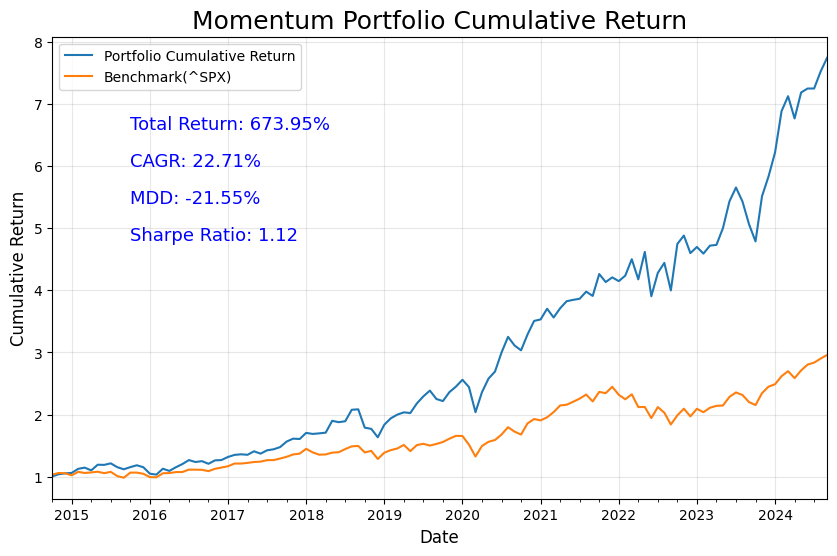

In [10]:
# 포트폴리오 총 수익률
portfolio_total_return = pf_cum_ret.iloc[-1] - 1

# 포트폴리오 CAGR
CAGR_portfolio = (pf_cum_ret.iloc[-1])**(1 / 10) - 1

# 샤프 비율 계산
risk_free_rate = 0.0
mon_ret = pf_cum_ret.pct_change()
mon_ret.iloc[0] = pf_cum_ret.iloc[0] - 1
mean_return = mon_ret.mean()*12
std_return = mon_ret.std()*np.sqrt(12)
sharpe_ratio = (mean_return - risk_free_rate) / std_return

# MDD 계산
MDD_portfolio = (pf_cum_ret / (pf_cum_ret.cummax()) - 1).min()

# 포트폴리오 누적 수익률 시각화
fig, ax = plt.subplots(figsize=(10,6))

pf_cum_ret.plot(ax=ax, label='Portfolio Cumulative Return')
benchmark = snp_cum_ret.resample('BME').last()
benchmark.plot(ax=ax,label='Benchmark(^SPX)')

ax.text(0.1, 0.8, f'Total Return: {100*portfolio_total_return:.2f}%', \
        transform=ax.transAxes, fontsize=13, color='blue')
ax.text(0.1, 0.72, f'CAGR: {100*CAGR_portfolio:.2f}%', transform=ax.transAxes,\
        fontsize=13, color='blue')
ax.text(0.1, 0.64, f'MDD: {100*MDD_portfolio:.2f}%', transform=ax.transAxes, \
        fontsize=13, color='blue')
ax.text(0.1, 0.56, f'Sharpe Ratio: {sharpe_ratio:.2f}', \
        transform=ax.transAxes, fontsize=13, color='blue')

ax.set_title('Momentum Portfolio Cumulative Return', fontsize=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return', fontsize=12)
ax.grid(alpha=0.3)
ax.legend()
plt.show()